# Import Libreries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from datetime import datetime
from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error 

import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-dark')

c:\Users\ddrodriguez\Documents\Python\conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def mean_absolute_percentage_error(y_true, y_pred):
    """Calcula el MAPE dando y_true y y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [3]:
df = pd.read_csv('IVE.csv',
                 index_col=[0],
                 parse_dates=[0])
#df.set_index(df['FechaProcedimiento'])

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6599 entries, 2006-01-02 to 2024-12-31
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Cantidad  6599 non-null   int64
dtypes: int64(1)
memory usage: 103.1 KB


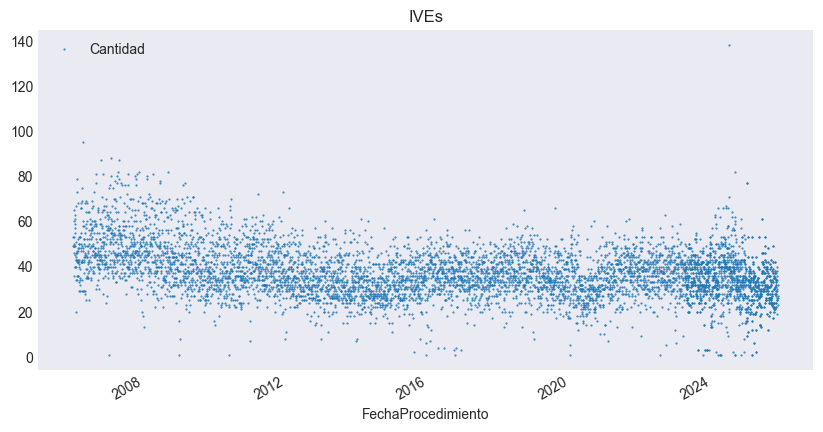

In [4]:
color_pal = sns.color_palette()

df.plot(style='.',
        figsize=(10,5),
        ms=1,
        color = color_pal[0],
        title="IVEs")

plt.show()

<Figure size 640x480 with 0 Axes>

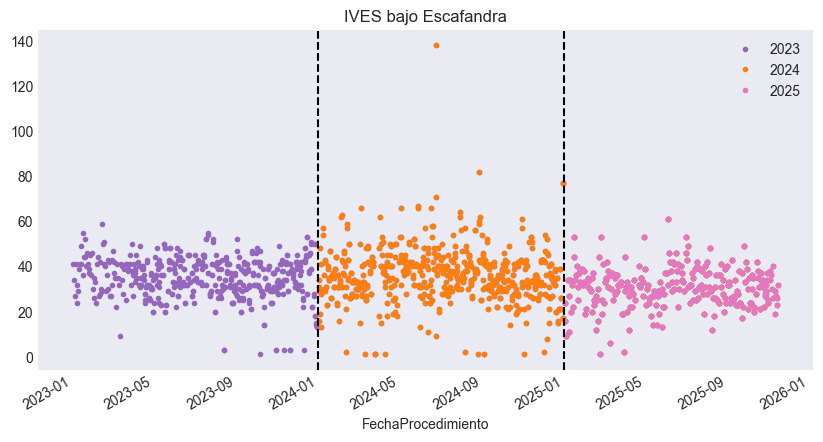

In [5]:
plt.figure()
fig, ax = plt.subplots(figsize=(10,5))
df.query("index > '2022-12-31'").plot(ax=ax,style='.',
                                      color=color_pal[4],
                                      title="IVES bajo Escafandra")
df.query("index > '2023-12-31'").plot(ax=ax,style='.',
                                      color=color_pal[1])
df.query("index > '2024-12-31'").plot(ax=ax,style='.',
                                      color=color_pal[6])
ax.axvline('2024-01-01', color='black', ls='--')
ax.axvline('2025-01-01', color='black', ls='--')
ax.legend(['2023','2024','2025'])
plt.show()

# Time Series Features

In [6]:
from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(categories=['Monday','Tuesday',
                                         'Wednesday',
                                         'Thursday','Friday',
                                         'Saturday','Sunday'],
                             ordered=True)

def create_features(df, label=None):
    '''
    Create time series features based on time series index
    '''
    df = df.copy()
    df['date'] = df.index
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_type)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year 
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300
    
    X = df[['dayofweek','quarter','month','year',
            'dayofyear','dayofmonth','weekday']]
    
    if label:
        y = df[label]
        return X, y
    return X 

X, y = create_features(df, label='Cantidad' )
features_and_target = pd.concat([X,y], axis=1)

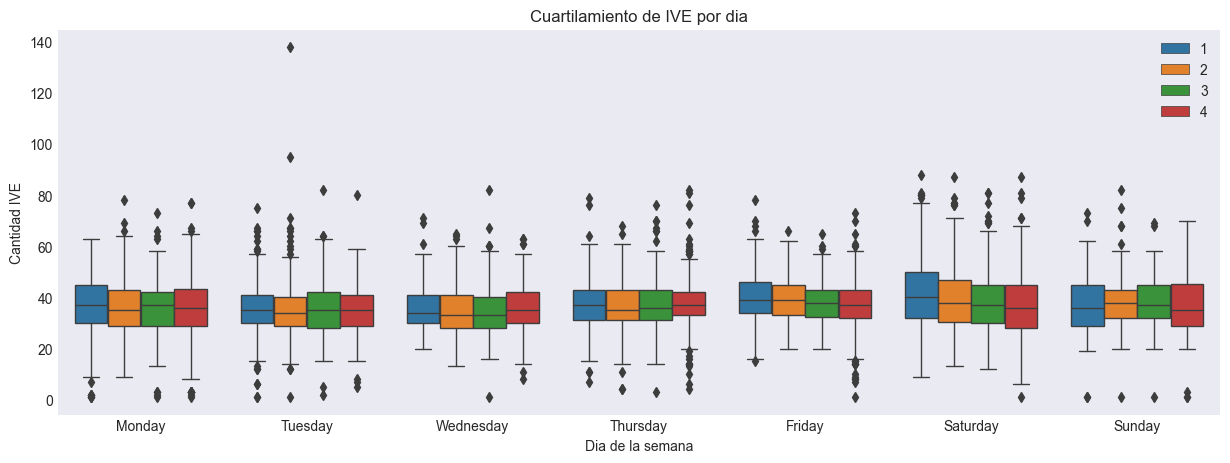

In [7]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot(data=features_and_target.dropna(),
            x='weekday',
            y='Cantidad',
            hue='quarter',
            ax=ax,
            linewidth=1)
ax.set_title('Cuartilamiento de IVE por dia')
ax.set_xlabel('Dia de la semana')
ax.set_ylabel('Cantidad IVE')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

# Train/Test Split

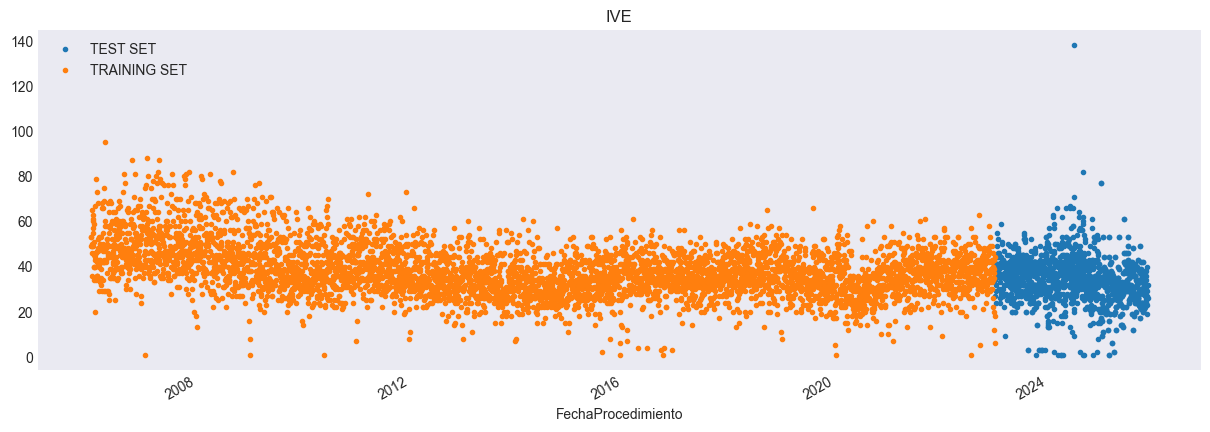

In [8]:
split_date = '01-01-2023'
train_ive = df.loc[df.index <= split_date].copy()
test_ive = df.loc[df.index > split_date].copy()

# Graficar train y test para visualizar lo que dividimos

test_ive\
        .rename(columns= {'Cantidad':'TEST SET'}) \
        .join (train_ive.rename(columns={'Cantidad':'TRAINING SET'}),
               how = 'outer') \
        .plot(figsize=(15,5), title='IVE', style='.')
plt.show()

# Prophet Model

In [9]:
train_prophet = train_ive.reset_index()\
    .rename(columns={'FechaProcedimiento':'ds',
                     'Cantidad':'y'})

In [10]:
%%time

model = Prophet()
model.fit(train_prophet)

11:02:23 - cmdstanpy - INFO - Chain [1] start processing
11:02:25 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 844 ms
Wall time: 4.49 s


In [11]:
test_prophet = test_ive.reset_index()\
    .rename(columns={'FechaProcedimiento':'ds',
                     'Cantidad':'y'})
    
ive_test_fcst = model.predict(test_prophet)

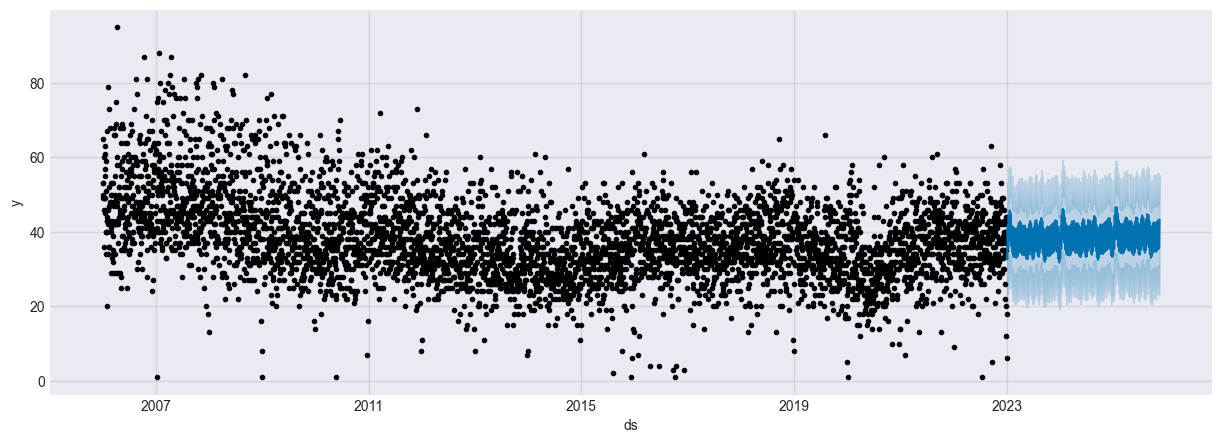

In [12]:
fig, ax = plt.subplots(figsize=(15,5))
fig = model.plot(ive_test_fcst, ax=ax)
plt.show()  

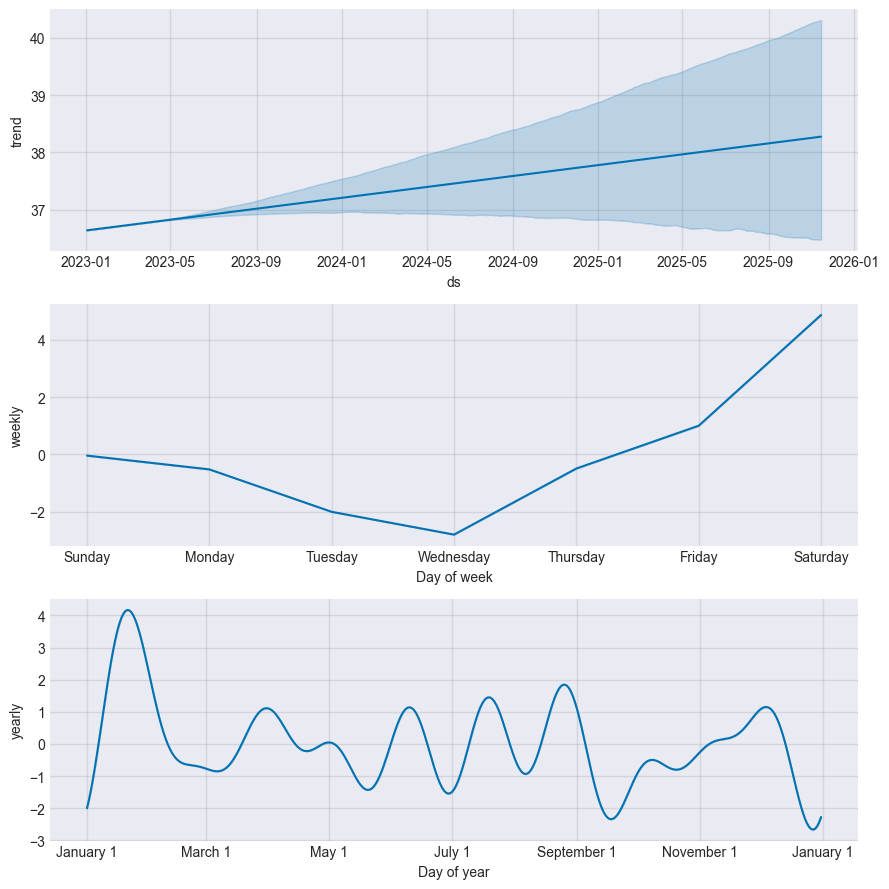

In [13]:
fig = model.plot_components(ive_test_fcst)
plt.show()

# Compare Forecast to Actuals

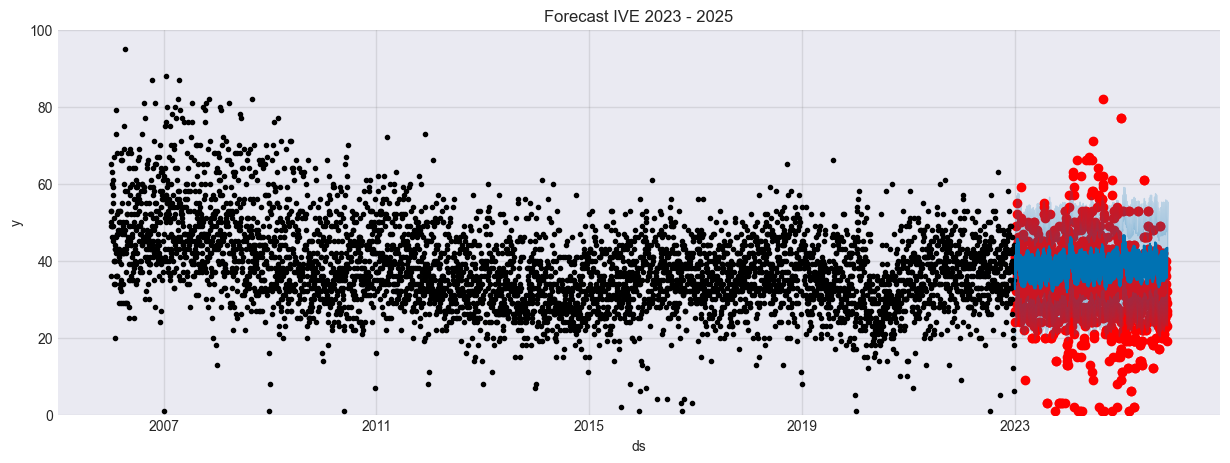

In [14]:
# Grafica del forecast versus los valores actuales total

f, ax = plt.subplots(figsize=(15,5))
ax.scatter(test_ive.index, test_ive['Cantidad'], color='r')
fig = model.plot(ive_test_fcst, ax=ax)
ax.set_ylim(0,100)
plot= plt.title('Forecast IVE 2023 - 2025')

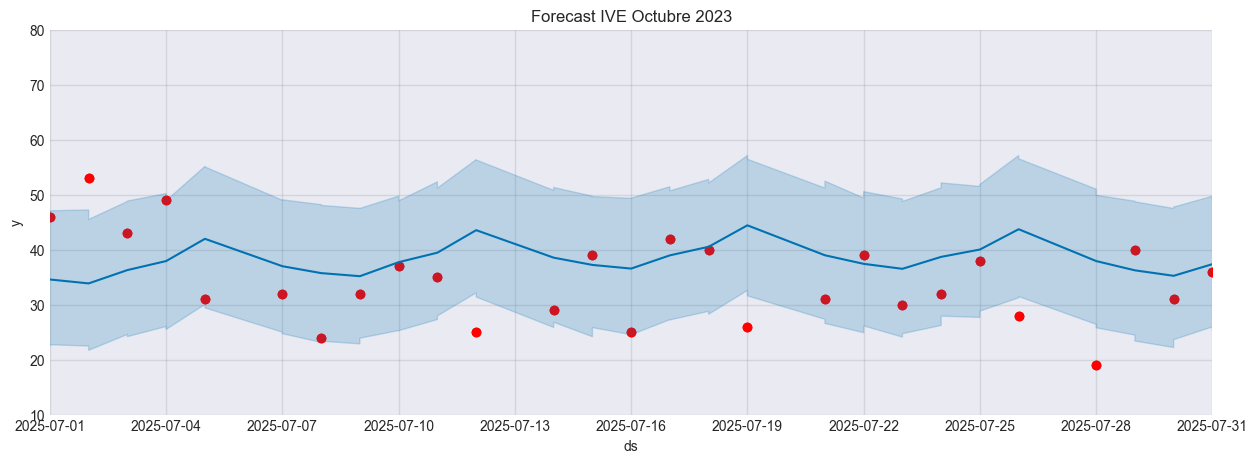

In [15]:
# Grafica del forecast versus los valores actuales primwer mes

fig, ax = plt.subplots(figsize=(15,5))
ax.scatter(test_ive.index, test_ive['Cantidad'], color='r')
fig = model.plot(ive_test_fcst, ax=ax)
ax.set_xbound(lower=pd.Timestamp('2025-07-01'),
              upper=pd.Timestamp('2025-07-31'))
ax.set_ylim(10,80)
plot= plt.title('Forecast IVE Octubre 2023')

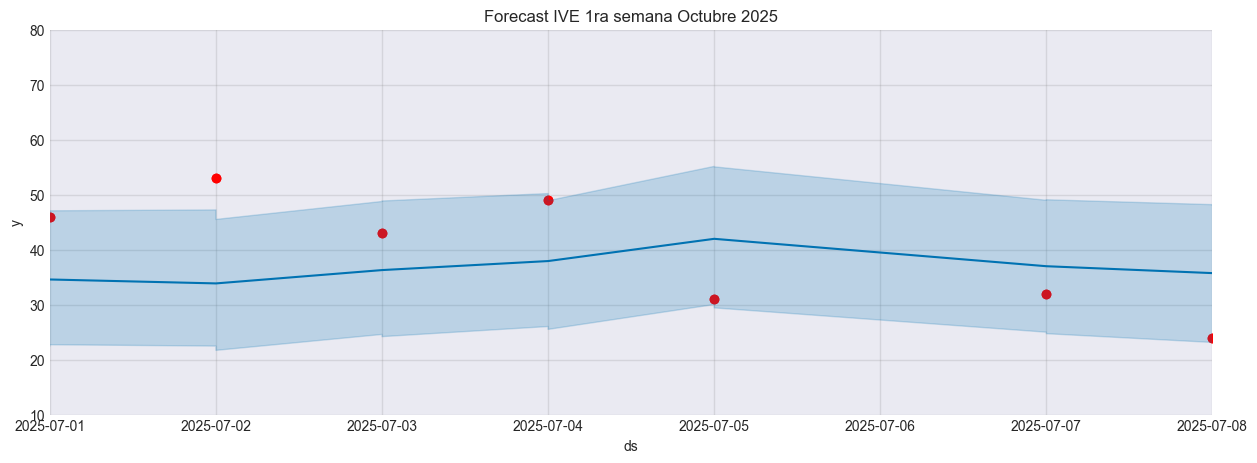

In [16]:
# Grafica del forecast versus los valores actuales primwer mes

fig, ax = plt.subplots(figsize=(15,5))
ax.scatter(test_ive.index, test_ive['Cantidad'], color='r')
fig = model.plot(ive_test_fcst, ax=ax)
ax.set_xbound(lower=pd.Timestamp('2025-07-01'),
              upper=pd.Timestamp('2025-07-08'))
ax.set_ylim(10,80)
plot= plt.title('Forecast IVE 1ra semana Octubre 2025')

# Predict the future

In [25]:
future = model.make_future_dataframe(periods=365*2, freq='D', include_history=False)
forecast = model.predict(future)

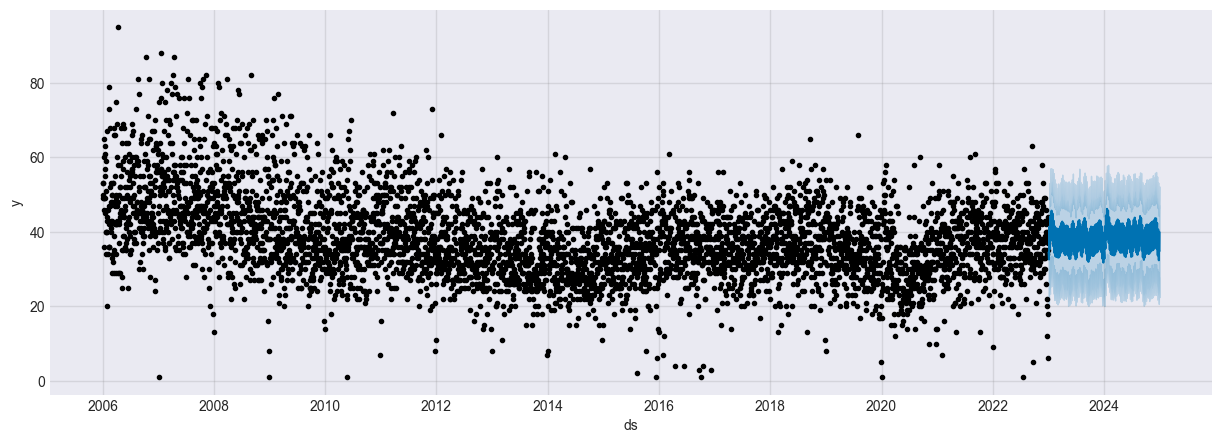

In [26]:
fig, ax = plt.subplots(figsize=(15,5))
fig = model.plot(forecast, ax=ax)
plt.show()  